# Rocket Engine Vibration Analysis Workbook
## Introduction to SRS, PSD, Spectrograms, and Filtering

**Learning Objectives:**
- Understand Power Spectral Density (PSD) and its relationship to FFT
- Learn about Shock Response Spectrum (SRS) for transient events
- Visualize time-varying frequency content with spectrograms
- Apply filtering techniques to clean noisy data
- Identify anomalies in vibration data during rocket engine testing


### Background

You've already learned about FFT (Fast Fourier Transform) from your beam vibration experiments. The FFT tells us **what frequencies are present** in a signal. Now we'll build on that foundation with more advanced analysis tools used in aerospace and mechanical testing.

**Test Setup:**
We have high-powered accelerometer data from 4 rocket engine tests:
- **Tests D (mcdowell), C (cy), W (Will Turrell):** 3D-printed thrust structures (slightly different designs)
- **Test Z:** Zip-tie structure

**Test Phases:**
1. **Pre-burn:** Static condition before ignition
2. **Burn Startup:** Engine ignition transient
3. **Steady Burn:** Constant thrust phase
4. **Burn Shutdown:** Engine cutoff transient  
5. **Blast Charge Deployment:** Parachute ejection event

 One of the time histories shows a strange spike during the burn phase in a certain freq range
 Part of your mission is to identify which test and understand what might be causing it

**AI STATEMENT**

you are expected to interpret all graphs without the use of AI.  The things you write in the notebook as answers to questions should be your own writing and oberservations.  You should not use AI to edit or clean up these responses.  All natural.

Honor pledge Partner names that you and your partner complied with the above____________________

AI can be used to understand the code, input variables, and write the coding section at the end.

If you used AI for the above, which tool did you use?  
how did you use it?

## Section 1: Setup and Data Loading

First, let's import our libraries and load the data.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt, stft, welch
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


In [2]:
# Function to load Dewesoft CSV data
def load_dewesoft_csv(filepath):
    """
    Load accelerometer data from Dewesoft CSV export.
    Expected format: Time [s], Acceleration [g] or [m/s²]
    """
    # Read CSV (Dewesoft typically exports with header)
    df = pd.read_csv(filepath)

    # Extract time and acceleration columns
    # Adjust column names based on your actual CSV format
    time_col = [col for col in df.columns if 's' in col.lower() or 'time' in col.lower()][0]
    accel_col = [col for col in df.columns if 'g' in col.lower() or 'm/s' in col.lower()][0]

    time = df[time_col].values
    accel = df[accel_col].values

    # Convert to g's if in m/s²
    if 'm/s' in accel_col:
        accel = accel / 9.81

    # Calculate sampling rate
    dt = np.mean(np.diff(time))
    fs = 1 / dt

    return time, accel, fs

print("✓ Data loading function ready!")

✓ Data loading function ready!


In [3]:
# Load from GitHub Repository
base_url = 'https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/data/'

files = {
    'D': 'Thrust Structure test mcdowell abel chase.csv',
    'C': 'Thrust Structure Testcy quinn Eastman.csv',
    'W': 'Thrust Structure Test Will kevin_go.csv',
    'Z': 'Thrust Structure test ZIP TIE.csv'
}

def load_github_csv(base_url, filename):
    url = base_url + filename.replace(' ', '%20')
    df = pd.read_csv(url)
    cols = df.columns.tolist()
    time_col = next((c for c in cols if 's' in c.lower()), cols[0])
    accel_col = next((c for c in cols if 'g' in c.lower() or 'm/s' in c.lower()), cols[1])
    time = df[time_col].values
    accel = df[accel_col].values
    if 'm/s' in accel_col.lower():
        accel = accel / 9.81
    fs = 1 / np.mean(np.diff(time))
    print(f"✓ {filename[:40]}: {len(time):,} samples @ {fs:.0f} Hz")
    return time, accel, fs

print("Loading from GitHub...\n")
time_d, acc_d, fs_d = load_github_csv(base_url, files['D'])
time_z, acc_z, fs_z = load_github_csv(base_url, files['Z'])
time_w, acc_w, fs_w = load_github_csv(base_url, files['W'])
time_c, acc_c, fs_c = load_github_csv(base_url, files['C'])
print("\n✅ All data loaded successfully!")

Loading from GitHub...

✓ Thrust Structure test mcdowell abel chas: 293,632 samples @ 10000 Hz
✓ Thrust Structure test ZIP TIE.csv: 337,152 samples @ 10000 Hz
✓ Thrust Structure Test Will kevin_go.csv: 330,624 samples @ 10000 Hz
✓ Thrust Structure Testcy quinn Eastman.cs: 328,448 samples @ 10000 Hz

✅ All data loaded successfully!


In [4]:
def detect_phases(time, accel, test_name='Unknown'):
    """
    Automatically detect burn and blast charge phases from acceleration data.

    Parameters:
    -----------
    time : array
        Time vector [s]
    accel : array
        Acceleration [g]
    test_name : str
        Name of the test for display

    Returns:
    --------
    phases : dict
        Dictionary with detected phase times
    """
    # Calculate envelope using absolute value and smoothing
    abs_accel = np.abs(accel)

    # Smooth with moving average to get envelope
    window = int(len(accel) / 1000)  # ~0.1% of data length
    if window < 10:
        window = 10
    envelope = np.convolve(abs_accel, np.ones(window)/window, mode='same')

    # Define threshold as multiple of baseline noise
    baseline_noise = np.percentile(envelope, 10)  # Bottom 10% is noise
    burn_threshold = baseline_noise + 0.5  # Adjust this if needed

    # Find regions above threshold
    burn_mask = envelope > burn_threshold

    # Find continuous regions (burn phases)
    burn_regions = []
    in_burn = False
    start_idx = 0

    for i in range(len(burn_mask)):
        if burn_mask[i] and not in_burn:
            # Start of burn
            start_idx = i
            in_burn = True
        elif not burn_mask[i] and in_burn:
            # End of burn
            if (i - start_idx) > 0.5 / np.mean(np.diff(time)):  # At least 0.5s duration
                burn_regions.append((time[start_idx], time[i-1]))
            in_burn = False

    # Close last region if still open
    if in_burn:
        burn_regions.append((time[start_idx], time[-1]))

    # Identify the main burn (longest duration above threshold)
    if len(burn_regions) > 0:
        burn_durations = [(end - start, start, end) for start, end in burn_regions]
        burn_durations.sort(reverse=True)

        # Main burn is the longest region
        main_burn_start = burn_durations[0][1]
        main_burn_end = burn_durations[0][2]

        # Subdivide burn into phases with SHORTER startup/shutdown
        burn_duration = main_burn_end - main_burn_start
        startup_duration = 0.1  # Fixed 0.1s startup
        shutdown_duration = 0.1  # Fixed 0.1s shutdown

        burn_startup = [main_burn_start, main_burn_start + startup_duration]
        burn_shutdown = [main_burn_end - shutdown_duration, main_burn_end]
        steady_burn = [burn_startup[1], burn_shutdown[0]]

        # Find blast charge using absolute threshold method
        # Look for |accel| > 1g at least 3 seconds after burn ends
        post_burn_time_threshold = main_burn_end + 3.0  # At least 3s after burn
        post_burn_mask = time > post_burn_time_threshold
        post_burn_abs_accel = abs_accel[post_burn_mask]
        post_burn_time = time[post_burn_mask]

        # Find where |accel| > 1g
        shock_mask = post_burn_abs_accel > 1.0

        if np.any(shock_mask):
            # Find the shock event
            shock_indices = np.where(shock_mask)[0]

            # Find peak location
            peak_idx = np.argmax(post_burn_abs_accel[shock_mask])
            actual_peak_idx = shock_indices[peak_idx]
            peak_time = post_burn_time[actual_peak_idx]

            # Define SHORT window around peak (±0.06s = 0.12s total)
            blast_charge = [peak_time - 0.06, peak_time + 0.06]
        else:
            blast_charge = None
    else:
        burn_startup = None
        steady_burn = None
        burn_shutdown = None
        blast_charge = None

    # Create phases dictionary
    phases_detected = {}
    if burn_startup:
        phases_detected['burn_startup'] = burn_startup
    if steady_burn:
        phases_detected['steady_burn'] = steady_burn
    if burn_shutdown:
        phases_detected['burn_shutdown'] = burn_shutdown
    if blast_charge:
        phases_detected['blast_charge'] = blast_charge

    # Print results
    print(f"\n{'='*60}")
    print(f"Automatic Phase Detection: {test_name}")
    print(f"{'='*60}")
    if burn_startup:
        print(f"  Burn Startup:   {burn_startup[0]:.3f} - {burn_startup[1]:.3f} s  ({burn_startup[1]-burn_startup[0]:.3f} s)")
    if steady_burn:
        print(f"  Steady Burn:    {steady_burn[0]:.3f} - {steady_burn[1]:.3f} s  ({steady_burn[1]-steady_burn[0]:.3f} s)")
    if burn_shutdown:
        print(f"  Burn Shutdown:  {burn_shutdown[0]:.3f} - {burn_shutdown[1]:.3f} s  ({burn_shutdown[1]-burn_shutdown[0]:.3f} s)")
    if blast_charge:
        print(f"  Blast Charge:   {blast_charge[0]:.3f} - {blast_charge[1]:.3f} s  ({blast_charge[1]-blast_charge[0]:.3f} s)")
    else:
        print(f"  Blast Charge:   NOT DETECTED")

    return phases_detected


# Automatically detect phases for all tests
print("\nAutomatic Phase Detection\n")

phases_auto = {}
phases_auto['Test D'] = detect_phases(time_d, acc_d, 'Test D - 3D Printed (McDowell/Abel/Chase)')
phases_auto['Test Z'] = detect_phases(time_z, acc_z, 'Test Z - Zip Tie')
phases_auto['Test W'] = detect_phases(time_w, acc_w, 'Test W - 3D Printed (Will/Kevin)')
phases_auto['Test C'] = detect_phases(time_c, acc_c, 'Test C - 3D Printed (Cy/Quinn/Eastman)')

# Use automatically detected phases
phases = phases_auto

print("\n" + "="*60)
print("✓ All phases automatically detected!")
print("="*60)


Automatic Phase Detection


Automatic Phase Detection: Test D - 3D Printed (McDowell/Abel/Chase)
  Burn Startup:   11.099 - 11.199 s  (0.100 s)
  Steady Burn:    11.199 - 11.888 s  (0.689 s)
  Burn Shutdown:  11.888 - 11.988 s  (0.100 s)
  Blast Charge:   17.780 - 17.900 s  (0.120 s)

Automatic Phase Detection: Test Z - Zip Tie
  Burn Startup:   10.831 - 10.931 s  (0.100 s)
  Steady Burn:    10.931 - 11.551 s  (0.620 s)
  Burn Shutdown:  11.551 - 11.651 s  (0.100 s)
  Blast Charge:   18.257 - 18.377 s  (0.120 s)

Automatic Phase Detection: Test W - 3D Printed (Will/Kevin)
  Burn Startup:   9.819 - 9.919 s  (0.100 s)
  Steady Burn:    9.919 - 10.525 s  (0.605 s)
  Burn Shutdown:  10.525 - 10.625 s  (0.100 s)
  Blast Charge:   16.777 - 16.897 s  (0.120 s)

Automatic Phase Detection: Test C - 3D Printed (Cy/Quinn/Eastman)
  Burn Startup:   9.429 - 9.529 s  (0.100 s)
  Steady Burn:    9.529 - 10.252 s  (0.723 s)
  Burn Shutdown:  10.252 - 10.352 s  (0.100 s)
  Blast Charge:   15.136 - 15.

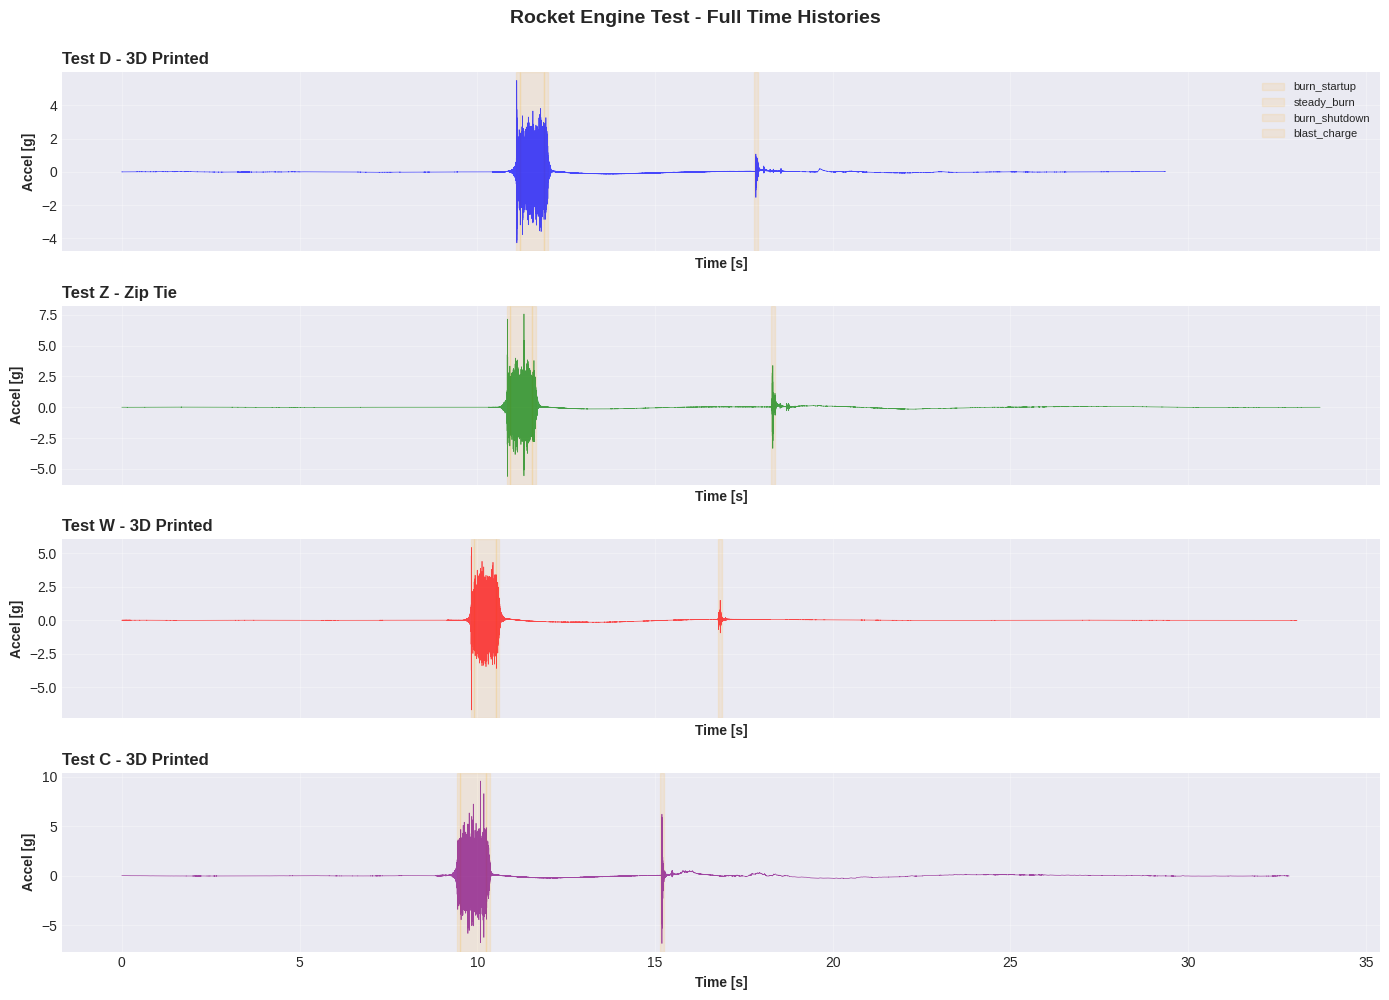

In [5]:
# Plot all four time histories
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

datasets = [
    (time_d, acc_d, 'Test D - 3D Printed', 'blue'),
    (time_z, acc_z, 'Test Z - Zip Tie', 'green'),
    (time_w, acc_w, 'Test W - 3D Printed', 'red'),
    (time_c, acc_c, 'Test C - 3D Printed', 'purple')
]

for i, (time, acc, label, color) in enumerate(datasets):
    axes[i].plot(time, acc, color=color, linewidth=0.5, alpha=0.7)
    axes[i].set_ylabel('Accel [g]', fontweight='bold')
    axes[i].set_xlabel('Time [s]', fontweight='bold')  # Add x-axis label to each
    axes[i].set_title(label, fontweight='bold', loc='left')
    axes[i].grid(True, alpha=0.3)

    # Add phase markers
    test_name = label.split(' - ')[0]
    for phase_name, (t_start, t_end) in phases[test_name].items():
        axes[i].axvspan(t_start, t_end, alpha=0.1, color='orange', label=phase_name if i == 0 else '')

axes[0].legend(loc='upper right', fontsize=8)
plt.suptitle('Rocket Engine Test - Full Time Histories', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## Section 2: Time History Overview

Let's start by looking at the raw acceleration time histories. This is your first chance to spot the anomaly!

### Student Exercise 1: Initial Observations

**Questions:**
1. Which tests show what looks like anomalous (not normal) behavior?
2. During which phase(s) do you see it?
3.  What else do you notice?

Answer Below.

## Section 3: High-Pass Filtering Explained

### What is Filtering?

From your beam vibration experiments, you know that signals can contain many different frequencies. **Filtering** allows us to remove unwanted frequency content:

- **High-Pass Filter:** Removes low frequencies, keeps high frequencies
- **Low-Pass Filter:** Removes high frequencies, keeps low frequencies  
- **Band-Pass Filter:** Keeps only a specific frequency range

### Why Filter?

In vibration testing:
- Remove DC offset (0 Hz - constant acceleration like gravity).  Our dynamic accelerometer requires in dewesoft that we have a 0.25 Hz (4 second period) high pass filter).  This causes some unfortunate strange effects in the time histories in the low frequencies.
- Eliminate high-frequency electrical noise
- Focus on frequencies of interest

### Filter Parameters

- **Cutoff Frequency:** The frequency where the filter starts working (in Hz)
- **Filter Order:** Higher order = sharper transition (but more processing)

Common practice: Use high-pass filter with cutoff at ~1-5 Hz to remove drift

### Filter Basics

**Definitions:**
*   **IIR (Infinite Impulse Response):** Feedback-based filters (like Butterworth).
*   **FIR (Finite Impulse Response):** Feedforward-based filters.

**Tradeoffs:**
*   **IIR vs. FIR:** IIR is **computationally efficient** (sharp cutoff with few calculations) but introduces phase shift (delays). FIR has **linear phase** (no shape distortion) but requires significantly more processing power to achieve the same sharpness.
*   **Filter Order:** A **higher order** creates a steeper cutoff (better noise removal) but increases computation time and potential signal ringing (overshoot).


In [6]:
def apply_filter(data, fs, filter_type='highpass', cutoff=1.0, cutoff_high=None, order=4):
    """
    Apply Butterworth filter to data.

    Parameters:
    -----------
    data : array
        Input signal
    fs : float
        Sampling frequency [Hz]
    filter_type : str
        Type of filter: 'highpass', 'lowpass', or 'bandpass'
    cutoff : float
        Cutoff frequency [Hz] (low cutoff for bandpass)
    cutoff_high : float
        High cutoff frequency [Hz] (only for bandpass)
    order : int
        Filter order (higher = sharper)

    Returns:
    --------
    filtered_data : array
        Filtered signal
    """
    nyquist = 0.5 * fs  # Nyquist frequency

    if filter_type == 'highpass':
        normal_cutoff = cutoff / nyquist
        b, a = butter(order, normal_cutoff, btype='high', analog=False)

    elif filter_type == 'lowpass':
        normal_cutoff = cutoff / nyquist
        b, a = butter(order, normal_cutoff, btype='low', analog=False)

    elif filter_type == 'bandpass':
        if cutoff_high is None:
            raise ValueError("cutoff_high must be specified for bandpass filter")
        low = cutoff / nyquist
        high = cutoff_high / nyquist
        b, a = butter(order, [low, high], btype='band', analog=False)

    else:
        raise ValueError("filter_type must be 'highpass', 'lowpass', or 'bandpass'")

    filtered_data = filtfilt(b, a, data)  # Zero-phase filtering
    return filtered_data

print("✓ Filter functions ready (highpass, lowpass, bandpass)!")

✓ Filter functions ready (highpass, lowpass, bandpass)!


### Interactive Filtering Exploration

**Experiment with these parameters and observe the effect:**

In [7]:
# ========================================
# 🎛️ ADJUST THESE PARAMETERS!
# =======================================
filter_type = 'lowpass'   # Choose: 'highpass', 'lowpass', or 'bandpass'
cutoff_freq = 1000        # Low cutoff (Hz) - for highpass/lowpass/bandpass
cutoff_high = 2000.0      # High cutoff (Hz) - only used for bandpass
filter_order = 2          # Try values: 2, 4, 6, 8
zoom_burn = True          # True = zoom to burn phase, False = full time
# ========================================

# Data dictionary
data_dict = {'D': (time_d, acc_d, fs_d), 'Z': (time_z, acc_z, fs_z),
             'W': (time_w, acc_w, fs_w), 'C': (time_c, acc_c, fs_c)}
colors = {'D': 'blue', 'Z': 'green', 'W': 'red', 'C': 'purple'}

# --- 1. Design Filter & Calculate Transfer Function
# We use the sampling rate of the first test (assuming all are same)
fs_design = data_dict['D'][2]
nyquist = 0.5 * fs_design

if filter_type == 'highpass':
    normal_cutoff = cutoff_freq / nyquist
    b, a = signal.butter(filter_order, normal_cutoff, btype='high', analog=False)
    filter_label = f'Highpass ({cutoff_freq} Hz, Order {filter_order})'
elif filter_type == 'lowpass':
    normal_cutoff = cutoff_freq / nyquist
    b, a = signal.butter(filter_order, normal_cutoff, btype='low', analog=False)
    filter_label = f'Lowpass ({cutoff_freq} Hz, Order {filter_order})'
elif filter_type == 'bandpass':
    low = cutoff_freq / nyquist
    high = cutoff_high / nyquist
    b, a = signal.butter(filter_order, [low, high], btype='band', analog=False)
    filter_label = f'Bandpass ({cutoff_freq}-{cutoff_high} Hz, Order {filter_order})'

# Calculate Frequency Response (Bode Plot)
w, h = signal.freqz(b, a, worN=2048, fs=fs_design)

# --- 2. Setup Plotting
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 2]})

# Plot 1: Filter Transfer Function
axes[0].plot(w, 20 * np.log10(abs(h)), 'g-', linewidth=2)
axes[0].set_title(f'Filter Frequency Response (Magnitude) - Order {filter_order}', fontweight='bold', loc='left')
axes[0].set_ylabel('Amplitude [dB]', fontweight='bold')
axes[0].grid(True, alpha=0.3, which='both')
axes[0].axhline(-3, color='k', linestyle='--', alpha=0.5, label='-3 dB Cutoff')
axes[0].set_ylim(-60, 5)
axes[0].set_xlim(0, fs_design/2)
axes[0].legend(loc='lower right')

# Plot 2: Filtered Signals (All Tests)
axes[1].set_title(f'Filtered Time Histories - Aligned at Burn Start ({filter_label})', fontweight='bold', loc='left')
axes[1].set_ylabel('Accel [g]', fontweight='bold')
axes[1].set_xlabel('Time relative to Burn Start [s]', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# --- 3. Filter and Plot Each Test
for test_name in ['D', 'Z', 'W', 'C']:
    time, acc, fs = data_dict[test_name]

    # Apply Zero-Phase Filter
    acc_filtered = signal.filtfilt(b, a, acc)

    # Align Time: Subtract start of burn phase
    # keys in 'phases' are like 'Test D', 'Test Z'...
    t_start_burn = phases[f'Test {test_name}']['burn_startup'][0]
    time_relative = time - t_start_burn

    # Plot
    axes[1].plot(time_relative, acc_filtered, color=colors[test_name], linewidth=0.8,
                 alpha=0.7, label=f'Test {test_name}')

axes[1].legend(loc='upper right')

# Zoom handling
if zoom_burn:
    # Zoom to region around burn (approx -0.5s to 1.5s relative time)
    axes[1].set_xlim(-0.5, 1.5)

plt.tight_layout()
plt.show()

print(f"\n📊 Filter Settings:")
print(f"  Filter Type: {filter_type.title()}")
print(f"  Filter Order: {filter_order}")
if filter_type == 'bandpass':
    print(f"  Passband: {cutoff_freq} - {cutoff_high} Hz")
else:
    print(f"  Cutoff Frequency: {cutoff_freq} Hz")
print(f"  Note: Comparison shows {filter_label} applied to all datasets.")

IndentationError: unexpected indent (200163132.py, line 56)

### 💡 Deep Dive: What is a Decibel (dB)?

In the Bode plot above, the Y-axis is in **Decibels (dB)**. This is a logarithmic unit used to describe the ratio of the output amplitude to the input amplitude.

$$ \text{Magnitude (dB)} = 20 \cdot \log_{10}\left(\frac{A_{out}}{A_{in}}\right) $$

**Why use dB?**
Filters can reduce signals by massive amounts (e.g., 1000x smaller). A linear plot would make small values invisible. The dB scale lets us see huge changes and tiny details on the same graph.

**Key Reference Points:**
*   **0 dB:** Ratio = 1. The signal passes through unchanged ($A_{out} = A_{in}$).
*   **-3 dB:** Ratio $\approx$ 0.707. The signal amplitude is reduced to 70.7%. This is the standard definition of the **"Cutoff Frequency"**.
*   **-6 dB:** Ratio = 0.5. The signal amplitude is cut in half.
*   **-20 dB:** Ratio = 0.1. The signal is 10% of its original size.
*   **-40 dB:** Ratio = 0.01. The signal is 1% of its original size.


1.  DC Drift

Settings: filter_type='lowpass', cutoff_freq=1000

Observe: The wavy baseline (up and down wandering) even when the engine is quiet.

Why? This is the DAQ's 0.25 Hz hardware filter reacting to the shock.  When we add a lowpass filter, these relics of the original filter in the DAQ get compunded into a larger dc drift phenomenon.  

2.  Manual Fix

Settings: filter_type='bandpass', cutoff_high=1000

Task: Start cutoff_freq at 0.1 and increase it (0.5, 1.0, 5.0).

Find: What lower frequency finally kills the drift problem?

3.  Instability

Settings: bandpass, cutoff_high=1000

Narrow frequency bands and high filter orders can lead to numerical instability.  Can you find the lowest filter order, n, that causes the filter to fail?

what about the lowest frequency as the lower cutoff that causes instability from the band being too narrow? (using n=4)

4.  Order Effects

Settings: bandpass, 40-200 Hz

Task: Compare Order 2 vs 8. Note how the green Bode plot gets "square shoulders.
".  Describe the changes to both the transfer function and the time histories.

5.  Frequency Scan (The Analysis)

Settings: Order=4
plot the following
8-50 Hz: Low freq rumble.
40-200 Hz: Mid-range structure.
200-1000 Hz: High freq noise.
over 2000 Hz: (highpass) Ultra-high hiss.

Comment on what you observe in the time histories of each.

Out of all the graphs, what stood out as the most anomalous?

## Section 4: Power Spectral Density (PSD)

### From FFT to PSD

You already know that FFT tells us what frequencies are in a signal. But a raw FFT has a problem: it gives you one noisy spectrum computed over the entire window you hand it. If that window is long, you get fine frequency resolution but the estimate is statistically unreliable. If it is short, the estimate is smoother but you lose frequency resolution.

PSD solves this by using Welch's method: divide the signal into many short, overlapping windows, compute the FFT of each one, and average the results. Averaging kills the random noise while preserving the true spectral shape.

### The Exact Math: FFT to PSD for One Window

Given a single time-domain window of $N$ samples, $x[n]$, and a window function $w[n]$ (e.g., Hann):

1. Apply the window: $\tilde{x}[n] = x[n] \cdot w[n]$

2. Take the FFT: $X[k] = \sum_{n=0}^{N-1} \tilde{x}[n]\, e^{-j2\pi kn/N}$

3. Compute the one-sided periodogram for frequency bin $k$:
$$S[k] = \frac{2\,|X[k]|^2}{f_s \cdot U}$$
where $f_s$ is the sampling rate and $U = \sum_{n=0}^{N-1} w[n]^2$ is the window power normalization factor that corrects for the energy removed by the window.

   The factor of 2 folds the negative-frequency energy into the positive side (one-sided spectrum). The division by $f_s \cdot U$ converts raw FFT magnitude squared into power *per unit frequency* (units: $\mathrm{g^2/Hz}$).

4. Repeat over all $M$ overlapping windows and average:
$$\hat{S}[k] = \frac{1}{M} \sum_{m=1}^{M} S_m[k]$$

This is what `scipy.signal.welch` computes. The frequency resolution of the result is $\Delta f = f_s / N$, so a larger window gives finer frequency bins.

### The Exact Math: gRMS

gRMS is the root-mean-square acceleration. It tells you the overall vibration intensity as a single number with units of g.

In the time domain, the RMS of a signal $x(t)$ over duration $T$ is:
$$x_{\mathrm{RMS}} = \sqrt{\frac{1}{T}\int_0^T x(t)^2\, dt}$$

Parseval's theorem connects this directly to the PSD. Integrating the PSD over all frequencies recovers the mean-square value of the signal:
$$\int_0^{f_{\max}} \hat{S}(f)\, df = x_{\mathrm{RMS}}^2$$

Therefore:
$$\mathrm{gRMS} = \sqrt{\int_0^{f_{\max}} \hat{S}(f)\, df}$$

In practice this integral is approximated numerically using the trapezoidal rule over the discrete frequency bins, which is exactly what `np.trapz(psd, freq)` computes in the code below.

What this means in the time history: gRMS is the standard deviation of the acceleration signal (assuming zero mean after high-pass filtering). It is not the peak, and it is not the average absolute value. It is the square root of the average of the squared signal. A signal with many large spikes scattered in time can have a high gRMS, but the gRMS will always be smaller than the peak acceleration seen in the time history. For a Gaussian random process, peaks reach roughly 3x the gRMS value about 0.3% of the time.

### Window Functions

The window function $w[n]$ applied to each segment before the FFT controls a tradeoff called spectral leakage. A rectangular window (no tapering) assumes the signal is periodic within each segment. When it is not, energy from a frequency leaks into adjacent bins and distorts the spectrum. Tapered windows suppress this leakage at the cost of slightly widening each peak.

Common options:
- Rectangular (boxcar): no tapering, sharpest frequency resolution, worst leakage
- Hann: moderate taper, good general-purpose choice, reduces leakage significantly
- Flattop: strong taper, excellent amplitude accuracy for tonal peaks, poor frequency resolution
- Blackman: strong taper, very low leakage, wider peaks than Hann

### Welch's Method — Key Parameters

- NFFT (nperseg): Number of points per window. Controls frequency resolution: $\Delta f = f_s / N$. Larger = finer resolution, fewer averages.
- Overlap: How much consecutive windows share. 50% is standard. More overlap = more averages = smoother estimate, but diminishing returns.
- Window function: See above.

In [ ]:
def compute_psd(data, fs, nperseg=1024, overlap_pct=50):
    """
    Compute Power Spectral Density using Welch's method.

    Parameters:
    -----------
    data : array
        Input signal
    fs : float
        Sampling frequency [Hz]
    nperseg : int
        Length of each segment (NFFT)
    overlap_pct : float
        Overlap percentage (0-100)

    Returns:
    --------
    freq : array
        Frequency bins [Hz]
    psd : array
        Power spectral density [g²/Hz]
    """
    noverlap = int(nperseg * overlap_pct / 100)
    freq, psd = welch(data, fs, nperseg=nperseg, noverlap=noverlap, window='hann', scaling='density')
    return freq, psd

print("✓ PSD computation function ready!")

### Interactive PSD Exploration


### Student Exercise 3: PSD Analysis

The code below computes and plots the PSD for all four tests on a log-log scale and prints the gRMS for each test.

The variable `window_size` controls the FFT segment length (NFFT). Larger values mean finer frequency resolution ($\Delta f = f_s / N$) but fewer averages, so each segment covers more time. Smaller values give coarser frequency resolution but more averages and a smoother estimate.

Run the cell three times with these values and observe what changes:

- window_size = 128
- window_size = 1024
- window_size = 8192

For each run, note what happens to the smoothness of the curves, whether the frequency peaks sharpen or blur, and whether the overall shape stays consistent. Then answer the questions in the observations cell below.

After reviewing the plots and gRMS values for all four tests, address these questions in your observations:
- Which test has the highest gRMS? Which has the lowest? What does that suggest about the relative severity of each test's vibration environment?
- Do all four tests share the same dominant frequency peaks, or do some tests show peaks that others do not?
- For each test, look back at the time history from Section 2. How does the gRMS value compare to the peak acceleration visible in the time history? Is the ratio roughly consistent across all four tests, or does one test show a notably large peak relative to its gRMS? What might cause that?


In [ ]:
# Rewrite of PSD Analysis to include gRMS and log-log plotting for all tests

# 1. Adjustable parameter
window_size = 500

fig, ax = plt.subplots(figsize=(14, 8))

colors = {'D': 'blue', 'Z': 'green', 'W': 'red', 'C': 'purple'}
test_names = ['D', 'Z', 'W', 'C']

print("Calculating PSD and gRMS for all tests...")

for test in test_names:
    # 3. Retrieve data
    if test in data_dict:
        time, acc, fs = data_dict[test]
    else:
        continue

    # 4. Apply 4th-order high-pass Butterworth filter (3 Hz cutoff)
    # Defining filter locally to ensure it works
    nyquist = 0.5 * fs
    cutoff = 3.0  # Hz
    b, a = signal.butter(4, cutoff / nyquist, btype='highpass', analog=False)
    acc_filt = signal.filtfilt(b, a, acc)

    # 5. Extract burn phase
    # phases dict keys are like 'Test D', 'Test Z'
    phase_key = f'Test {test}'
    if phase_key in phases:
        t_start = phases[phase_key]['burn_startup'][0]
        t_end = phases[phase_key]['burn_shutdown'][1]

        mask = (time >= t_start) & (time <= t_end)
        acc_burn = acc_filt[mask]

        # 6. Compute PSD
        freq, psd = signal.welch(acc_burn, fs, nperseg=window_size)

        # 7. Calculate gRMS (Root Mean Square acceleration)
        # gRMS = sqrt(integral(PSD))
        grms = np.sqrt(np.trapz(psd, freq))

        # 8. Plot on log-log scale
        ax.loglog(freq, psd, color=colors[test], linewidth=1.5, alpha=0.8,
                  label=f'Test {test}: {grms:.2f} gRMS')

# 10. Formatting
ax.set_xlabel('Frequency [Hz]', fontweight='bold', fontsize=12)
ax.set_ylabel('PSD [g²/Hz]', fontweight='bold', fontsize=12)
ax.set_title(f'PSD Comparison - All Tests (window_size={window_size})', fontweight='bold', fontsize=14)
ax.grid(True, which="both", ls="-", alpha=0.5)
ax.legend(fontsize=12)
ax.set_xlim(10, 5000)  # Focus on relevant frequency range

plt.tight_layout()
plt.show()

Record your observations here.

Effect of changing window_size on the PSD curves:



Differences in gRMS and spectral shape between the four tests:



gRMS vs. peak acceleration in the time history:




## Section 5: Spectrograms (Time-Frequency Analysis)

### The Limitation of FFT and PSD

FFT and PSD both lose time information. A PSD tells you that a certain frequency was energetic during the burn phase — but it cannot tell you whether that energy was spread evenly across the burn or concentrated in a short burst. A spectrogram recovers this by computing a short-time FFT at many consecutive, overlapping windows and displaying the result as a 2D image: time on the x-axis, frequency on the y-axis, and signal power encoded in color.

### How It Works

The spectrogram is computed using the Short-Time Fourier Transform (STFT). The signal is split into overlapping windows, each windowed with a Hann function (same reasoning as in Section 4 — reduces spectral leakage), and an FFT is taken of each. The magnitude squared of the FFT gives the power at each time-frequency point. The result is a matrix where each column is the power spectrum at one time step.

### The Core Tradeoff

Every spectrogram parameter is a dial between two competing things: time resolution vs. frequency resolution. These are fundamentally linked — you cannot improve both at the same time.

A long window gives you fine frequency resolution (small $\Delta f = f_s / N$) but poor time resolution, because each column of the spectrogram represents a long chunk of time. A short window gives you sharp time resolution but smears the frequency axis. This is the time-frequency uncertainty principle, and it applies to every spectrogram you will ever make.

The other knobs — overlap, colormap, frequency axis scale, power scale — control how clearly the data is displayed rather than what is computed, but they have a large effect on what you can actually see.

Parameter summary:
- window_size (nperseg): Number of samples per FFT window. Controls time vs. frequency resolution tradeoff.
- overlap: Fraction of each window shared with the next. Higher overlap = smoother time axis, more computation. 75-90% is typical.
- freq_max: Upper limit of the displayed frequency axis. Cropping to the relevant range avoids wasting plot space.
- freq_scale: 'linear' or 'log'. A log frequency axis spreads out low-frequency content and compresses high-frequency content, which often makes broadband data easier to read.
- power_scale: Whether to display power in dB (log scale) or linear. dB is almost always better for vibration data because the dynamic range spans many orders of magnitude.
- colormap: Controls which colors map to which power levels. 'turbo' gives a perceptually uniform range from dark blue (low power) to bright yellow (high power). 'jet' is common but has known perceptual distortion issues. 'viridis' and 'plasma' are alternatives.

We are only going to look at the spectrograms from test z to save time and because z has some interesting features.  

In [ ]:
from scipy.signal import stft

def compute_spectrogram(data, fs, nperseg=512, overlap_pct=75):
    """
    Compute a power spectrogram via STFT.

    Parameters
    -----------
    data : array
        Input signal (time domain)
    fs : float
        Sampling frequency [Hz]
    nperseg : int
        Samples per FFT window. Sets frequency resolution: df = fs / nperseg.
        Larger = finer frequency resolution, coarser time resolution.
    overlap_pct : float
        Window overlap as a percentage (0-100).
        Higher = smoother time axis, more columns in output.

    Returns
    ----    t : array
        Time bins [s]
    f : array
        Frequency bins [Hz]
    Sxx : 2D array
        Power at each (frequency, time) point [g^2]
    """
    noverlap = int(nperseg * overlap_pct / 100)
    f, t, Zxx = stft(data, fs, nperseg=nperseg, noverlap=noverlap, window='hann')
    Sxx = np.abs(Zxx) ** 2  # Convert complex STFT to power
    return t, f, Sxx

print("Spectrogram function ready.")


### Spectrogram Parameter Study — Test Z


In [ ]:
# Spectrogram parameter study using Test Z
# All combinations below are computed and plotted so you can compare them directly.
# The filtering follows the same approach established in Section 3:
# a 4th-order Butterworth high-pass filter at 3 Hz removes the DC drift artifact.

from scipy.signal import butter, filtfilt

# --- Load and filter Test Z data
time_z_s, acc_z_s, fs_z_s = data_dict['Z']
nyq = 0.5 * fs_z_s
b_hp, a_hp = butter(4, 3.0 / nyq, btype='highpass')
acc_z_filt = filtfilt(b_hp, a_hp, acc_z_s)

# --- Parameter combinations to explore
# Each entry: (window_size, overlap_pct, freq_max, freq_scale, power_scale, colormap, label)
configs = [
    # Vary window size — shows time vs frequency resolution tradeoff
    (128,  75, 2500, 'linear', 'dB',     'turbo',   'A: Short window (128), linear freq, dB'),
    (1024, 75, 2500, 'linear', 'dB',     'turbo',   'B: Long window (1024), linear freq, dB'),
    (4096, 75, 2500, 'linear', 'dB',     'turbo',   'C: Very long window (4096), linear freq, dB'),

    # Vary overlap — shows effect on time axis smoothness
    (512,  25, 2500, 'linear', 'dB',     'turbo',   'D: Low overlap (25%), dB'),
    (512,  90, 2500, 'linear', 'dB',     'turbo',   'E: High overlap (90%), dB'),

    # Log vs linear frequency axis
    (512,  75, 2500, 'log',    'dB',     'turbo',   'F: Log freq axis, dB'),
    (512,  75, 2500, 'linear', 'dB',     'turbo',   'G: Linear freq axis, dB'),

    # dB vs linear power scale
    (512,  75, 2500, 'linear', 'linear', 'turbo',   'H: Linear power scale (not dB)'),
    (512,  75, 2500, 'linear', 'dB',     'turbo',   'I: dB power scale'),

    # Colormap comparison
    (512,  75, 2500, 'linear', 'dB',     'turbo',   'J: Colormap turbo'),
    (512,  75, 2500, 'linear', 'dB',     'viridis', 'K: Colormap viridis'),
    (512,  75, 2500, 'linear', 'dB',     'jet',     'L: Colormap jet'),
]

# --- Plot all configurations
n_cols = 3
n_rows = int(np.ceil(len(configs) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.8))
axes = axes.flatten()

for idx, (nperseg, overlap_pct, freq_max, freq_scale, power_scale, cmap, label) in enumerate(configs):
    t_s, f_s, Sxx = compute_spectrogram(acc_z_filt, fs_z_s, nperseg=nperseg, overlap_pct=overlap_pct)
    t_s = t_s + time_z_s[0]  # align to original time axis

    freq_mask = f_s <= freq_max
    f_plot = f_s[freq_mask]
    S_plot = Sxx[freq_mask, :]

    if power_scale == 'dB':
        Z_plot = 10 * np.log10(S_plot + 1e-12)
        vmin, vmax = np.percentile(Z_plot, 5), np.percentile(Z_plot, 99)
        clabel = 'Power [dB]'
    else:
        Z_plot = S_plot
        vmin, vmax = 0, np.percentile(Z_plot, 98)
        clabel = 'Power [g^2]'

    ax = axes[idx]
    pcm = ax.pcolormesh(t_s, f_plot, Z_plot, shading='gouraud',
                        cmap=cmap, vmin=vmin, vmax=vmax)

    if freq_scale == 'log':
        ax.set_yscale('log')
        ax.set_ylim(max(f_plot[f_plot > 0].min(), 5), freq_max)

    ax.set_title(label, fontsize=8)
    ax.set_xlabel('Time [s]', fontsize=8)
    ax.set_ylabel('Freq [Hz]', fontsize=8)
    ax.tick_params(labelsize=7)
    plt.colorbar(pcm, ax=ax, label=clabel, pad=0.02).ax.tick_params(labelsize=7)

    # Print resolution info
    df = fs_z_s / nperseg
    dt_step = (nperseg * (1 - overlap_pct / 100)) / fs_z_s * 1000
    print(f"{label[:1]}: window={nperseg}, overlap={overlap_pct}%  |  freq res={df:.1f} Hz, time step={dt_step:.1f} ms")

# Hide any unused axes
for j in range(len(configs), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Test Z — Spectrogram Parameter Study', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Student Exercise 4: Spectrogram Analysis

Review the 12 plots above. Each one was produced from the same Test Z data with one or two parameters changed at a time. Use the printed resolution summary (frequency resolution in Hz and time step in ms) printed below each plot to support your answers.

Answer the following in the observations cell below:

Window size (compare A, B, C):
Describe what happens to the appearance of narrow frequency peaks as the window grows. What do you lose as the window gets longer? Can you still locate the burn startup in time on plot C?

Overlap (compare D and E):
What does increasing overlap from 25% to 90% do to the time axis? Does it change what information is present, or just how it looks?

Frequency axis scale (compare F and G):
Which scale makes the low-frequency content easier to examine? Which makes high-frequency content easier? For this dataset, which do you prefer and why?

Power scale — dB vs. linear (compare H and I):
What happens to the dynamic range when you switch to linear power? Can you still see the low-level features? Explain in terms of what dB scaling is actually doing mathematically.

Colormap (compare J, K, L):
Describe a qualitative difference between turbo, viridis, and jet. Is there any combination that makes it harder to judge where one power level ends and another begins?

Best overall:
Choose the single configuration (or describe a configuration combining settings from different plots) that you think makes the data most understandable. Justify your choice. Refer to specific features in the Test Z data that your chosen settings reveal most clearly.

Patterns in the data:
Across all plots, identify at least two distinct frequency features you can consistently locate. Note their approximate frequency range and whether they are present throughout the burn or only during a specific phase.


**Spectrograms for Just Engine Burn Phase**

In [ ]:
# Spectrogram parameter study — Test Z, engine burn phase only

from scipy.signal import butter, filtfilt

# --- Load and filter Test Z data
time_z_s, acc_z_s, fs_z_s = data_dict['Z']
nyq = 0.5 * fs_z_s
b_hp, a_hp = butter(4, 3.0 / nyq, btype='highpass')
acc_z_filt = filtfilt(b_hp, a_hp, acc_z_s)

# --- Slice to engine burn only
t_burn_start = phases['Test Z']['burn_startup'][0]
t_burn_end   = phases['Test Z']['burn_shutdown'][1]
burn_mask = (time_z_s >= t_burn_start) & (time_z_s <= t_burn_end)
acc_burn  = acc_z_filt[burn_mask]
time_burn = time_z_s[burn_mask]

# --- Parameter combinations to explore
# Each entry: (window_size, overlap_pct, freq_max, freq_scale, power_scale, colormap, label)
configs = [
    # Vary window size — time vs. frequency resolution tradeoff
    (128,  75, 2500, 'linear', 'dB',     'turbo',   'A: Short window (128), linear freq, dB'),
    (1024, 75, 2500, 'linear', 'dB',     'turbo',   'B: Long window (1024), linear freq, dB'),
    (4096, 75, 2500, 'linear', 'dB',     'turbo',   'C: Very long window (4096), linear freq, dB'),

    # Vary overlap
    (512,  25, 2500, 'linear', 'dB',     'turbo',   'D: Low overlap (25%), dB'),
    (512,  90, 2500, 'linear', 'dB',     'turbo',   'E: High overlap (90%), dB'),

    # Log vs. linear frequency axis
    (512,  75, 2500, 'log',    'dB',     'turbo',   'F: Log freq axis, dB'),
    (512,  75, 2500, 'linear', 'dB',     'turbo',   'G: Linear freq axis, dB'),

    # dB vs. linear power scale
    (512,  75, 2500, 'linear', 'linear', 'turbo',   'H: Linear power scale (not dB)'),
    (512,  75, 2500, 'linear', 'dB',     'turbo',   'I: dB power scale'),

    # Colormap comparison
    (512,  75, 2500, 'linear', 'dB',     'turbo',   'J: Colormap turbo'),
    (512,  75, 2500, 'linear', 'dB',     'viridis', 'K: Colormap viridis'),
    (512,  75, 2500, 'linear', 'dB',     'jet',     'L: Colormap jet'),
]

# --- Plot all configurations
n_cols = 3
n_rows = int(np.ceil(len(configs) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.8))
axes = axes.flatten()

for idx, (nperseg, overlap_pct, freq_max, freq_scale, power_scale, cmap, label) in enumerate(configs):
    t_s, f_s, Sxx = compute_spectrogram(acc_burn, fs_z_s, nperseg=nperseg, overlap_pct=overlap_pct)
    t_s = t_s + time_burn[0]  # align to original time axis

    freq_mask = f_s <= freq_max
    f_plot = f_s[freq_mask]
    S_plot = Sxx[freq_mask, :]

    if power_scale == 'dB':
        Z_plot = 10 * np.log10(S_plot + 1e-12)
        vmin, vmax = np.percentile(Z_plot, 5), np.percentile(Z_plot, 99)
        clabel = 'Power [dB]'
    else:
        Z_plot = S_plot
        vmin, vmax = 0, np.percentile(Z_plot, 98)
        clabel = 'Power [g^2]'

    ax = axes[idx]
    pcm = ax.pcolormesh(t_s, f_plot, Z_plot, shading='gouraud',
                        cmap=cmap, vmin=vmin, vmax=vmax)

    if freq_scale == 'log':
        ax.set_yscale('log')
        ax.set_ylim(max(f_plot[f_plot > 0].min(), 5), freq_max)

    ax.set_title(label, fontsize=8)
    ax.set_xlabel('Time [s]', fontsize=8)
    ax.set_ylabel('Freq [Hz]', fontsize=8)
    ax.tick_params(labelsize=7)
    plt.colorbar(pcm, ax=ax, label=clabel, pad=0.02).ax.tick_params(labelsize=7)

    df = fs_z_s / nperseg
    dt_step = (nperseg * (1 - overlap_pct / 100)) / fs_z_s * 1000
    print(f"{label[:1]}: window={nperseg}, overlap={overlap_pct}%  |  freq res={df:.1f} Hz, time step={dt_step:.1f} ms")

for j in range(len(configs), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Test Z — Spectrogram Parameter Study (Burn: {t_burn_start:.1f}s – {t_burn_end:.1f}s)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Student Exercise 4: Spectrogram Analysis

Review the 12 plots above. Each one was produced from the same Test Z data with one or two parameters changed at a time. Use the printed resolution summary (frequency resolution in Hz and time step in ms) printed below each plot to support your answers.

Best overall:
Choose the single configuration (or describe a configuration combining settings from different plots) that you think makes the data most understandable. Justify your choice. Refer to specific features in the Test Z data that your chosen settings reveal most clearly.

What are the 2 vertical lines in the data? do they share the same frequency content?  

## Section 6: Shock Response Spectrum (SRS)

### What is SRS?

The Shock Response Spectrum answers one specific question: if this measured acceleration were applied as a base input to a lightly-damped single-degree-of-freedom (SDOF) oscillator, what is the largest acceleration response that oscillator would ever see? By sweeping that question across a range of natural frequencies, you get a curve that encodes the damage potential of the event as a function of frequency. Any structure or component whose natural frequency falls in a region of high SRS is at risk.

SRS is the right tool for transient events — startup pulses, pyrotechnic firings, blast charges, stage separations — where PSD would smear the energy across a time-averaged spectrum and lose the peak content.

### The Q Factor

Every SDOF oscillator in the SRS calculation has a damping ratio $\zeta$. In SRS work, damping is almost always expressed as the Q factor instead:

$$Q = \frac{1}{2\zeta}$$

A high Q means low damping — the oscillator rings for a long time after excitation and builds up a large response. A low Q means high damping — the oscillator absorbs energy quickly and responds less violently.

Common values and their physical meaning:

- Q = 5 ($\zeta$ = 10%): heavily damped. Representative of components with significant structural damping, constrained-layer treatments, or mounting compliance.
- Q = 10 ($\zeta$ = 5%): the aerospace standard default. Used in MIL-STD-810, ECSS, and NASA test specs when no measured damping data is available.
- Q = 25 ($\zeta$ = 2%): lightly damped. Appropriate for stiff metallic structures, printed circuit boards with no conformal coating, or any structure where damping has been measured to be low.
- Q = 50 ($\zeta$ = 1%): very lightly damped. Used for worst-case bounding analyses or when evaluating components known to have very little energy dissipation.

The choice of Q does not change what actually happened — it changes how sensitive you assume the components to be. A higher Q produces a higher SRS curve from the same data. In practice, Q = 10 is used for specification and qualification testing, while Q = 25 or 50 may be used to evaluate worst-case component survivability.

### Smallwood Ramp Invariant Method

The industry-standard algorithm for computing SRS is the Smallwood ramp invariant recursive filter. It models each SDOF oscillator as a second-order IIR digital filter and sweeps the input signal through it. It is numerically stable, efficient, and produces results consistent with analog filter theory even at high frequencies relative to the sampling rate.

In [ ]:
from scipy import signal as _signal

def srs_smallwood(accel, fs, freq_bins, Q=10):
    """
    Compute the Shock Response Spectrum using the Smallwood ramp invariant method.

    Parameters
    -----------
    accel : array
        Acceleration time history [g]. Should already be filtered
        (4th-order Butterworth high-pass at 3 Hz per Section 3 practice).
    fs : float
        Sampling frequency [Hz]
    freq_bins : array
        Natural frequencies at which to evaluate the SRS [Hz]
    Q : float
        Quality factor. Damping ratio zeta = 1 / (2*Q).
        Q=10 -> 5% damping (aerospace default)
        Q=25 -> 2% damping (lightly damped structures)

    Returns
    ----    srs : array
        Maximum absolute acceleration response [g] at each frequency in freq_bins
    """
    dt = 1.0 / fs
    srs = np.zeros(len(freq_bins))

    for i, fn in enumerate(freq_bins):
        wn   = 2 * np.pi * fn
        zeta = 1.0 / (2.0 * Q)
        wd   = wn * np.sqrt(1.0 - zeta**2)

        E       = np.exp(-zeta * wn * dt)
        K       = dt * wd
        C       = E * np.cos(K)
        S       = E * np.sin(K)
        S_prime = S / K if K != 0 else 1.0

        b0 = 1.0 - S_prime
        b1 = 2.0 * (S_prime - C)
        b2 = E**2 - S_prime
        a1 = -2.0 * C
        a2 = E**2

        b_coef = np.array([b0, b1, b2])
        a_coef = np.array([1.0, a1, a2])

        y = _signal.lfilter(b_coef, a_coef, accel)
        srs[i] = np.max(np.abs(y))

    return srs


def filter_highpass(data, fs, cutoff=3.0, order=4):
    """4th-order Butterworth high-pass filter, consistent with Section 3."""
    from scipy.signal import butter, filtfilt
    b, a = butter(order, cutoff / (0.5 * fs), btype='highpass')
    return filtfilt(b, a, data)


freq_bins_srs = np.logspace(np.log10(10), np.log10(5000), 120)

print("SRS function ready.")
print(f"Frequency range: {freq_bins_srs[0]:.0f} – {freq_bins_srs[-1]:.0f} Hz ({len(freq_bins_srs)} bins)")


### Effect of Q on the SRS — Test Z


In [ ]:
# Plot 1: Burn-phase SRS at Q = 5, 10, 25, 50  (Test Z)
# Plot 2: Blast-charge SRS at Q = 5, 10, 25, 50 (Test Z)
#
# Filtering: 4th-order Butterworth high-pass at 3 Hz, consistent with Section 3.

time_z, acc_z, fs_z = data_dict['Z']
acc_z_hp = filter_highpass(acc_z, fs_z, cutoff=3.0, order=4)

Q_values = [5, 10, 25, 50]
Q_colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']

# --- Phase masks
burn_start = phases['Test Z']['burn_startup'][0]
burn_end   = phases['Test Z']['burn_shutdown'][1]
blast_start, blast_end = phases['Test Z']['blast_charge']

acc_burn_z  = acc_z_hp[(time_z >= burn_start) & (time_z <= burn_end)]
acc_blast_z = acc_z_hp[(time_z >= blast_start) & (time_z <= blast_end)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for Q, color in zip(Q_values, Q_colors):
    zeta_pct = 100 / (2 * Q)
    print(f"Computing Q={Q} (zeta={zeta_pct:.1f}%)...")

    srs_burn  = srs_smallwood(acc_burn_z,  fs_z, freq_bins_srs, Q=Q)
    srs_blast = srs_smallwood(acc_blast_z, fs_z, freq_bins_srs, Q=Q)

    ax1.loglog(freq_bins_srs, srs_burn,  color=color, linewidth=2,
               label=f'Q={Q}  (zeta={zeta_pct:.0f}%)')
    ax2.loglog(freq_bins_srs, srs_blast, color=color, linewidth=2,
               label=f'Q={Q}  (zeta={zeta_pct:.0f}%)')

for ax, title in [(ax1, 'Test Z — Full Burn SRS'),
                  (ax2, 'Test Z — Blast Charge SRS')]:
    ax.set_xlabel('Natural Frequency [Hz]', fontsize=11)
    ax.set_ylabel('Max Response [g]', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, which='both', alpha=0.4)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Done.")


### Student Exercise 5: SRS Analysis


In [ ]:
# --- Plot A: SRS for multiple phases of Test Z at Q=25
# Phases shown: full test, full burn, burn startup, burn shutdown, blast charge

Q_study = 25

time_z, acc_z, fs_z = data_dict['Z']
acc_z_hp = filter_highpass(acc_z, fs_z, cutoff=3.0, order=4)

phase_defs = [
    ('Full Test',      time_z[0],                          time_z[-1]),
    ('Full Burn',      phases['Test Z']['burn_startup'][0], phases['Test Z']['burn_shutdown'][1]),
    ('Burn Startup',   phases['Test Z']['burn_startup'][0], phases['Test Z']['burn_startup'][1]),
    ('Burn Shutdown',  phases['Test Z']['burn_shutdown'][0],phases['Test Z']['burn_shutdown'][1]),
    ('Blast Charge',   phases['Test Z']['blast_charge'][0], phases['Test Z']['blast_charge'][1]),
]
phase_colors = ['black', 'steelblue', 'darkorange', 'crimson', 'forestgreen']
phase_styles = ['-', '-', '--', '--', '-']

fig, ax = plt.subplots(figsize=(14, 7))

for (label, t0, t1), color, ls in zip(phase_defs, phase_colors, phase_styles):
    seg = acc_z_hp[(time_z >= t0) & (time_z <= t1)]
    print(f"Computing SRS: {label} ({t1-t0:.2f}s)...")
    srs = srs_smallwood(seg, fs_z, freq_bins_srs, Q=Q_study)
    ax.loglog(freq_bins_srs, srs, color=color, linewidth=2, linestyle=ls, label=label)

ax.set_xlabel('Natural Frequency [Hz]', fontsize=12)
ax.set_ylabel('Max Response [g]', fontsize=12)
ax.set_title(f'Test Z — SRS by Phase  (Q={Q_study})', fontsize=13)
ax.grid(True, which='both', alpha=0.4)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# --- Plot B: Full burn SRS, all tests at Q=25
fig, ax = plt.subplots(figsize=(14, 7))
test_colors = {'D': 'steelblue', 'Z': 'forestgreen', 'W': 'crimson', 'C': 'darkorchid'}
test_labels = {'D': 'Test D (3D printed)', 'Z': 'Test Z (zip-tie)',
               'W': 'Test W (3D printed)', 'C': 'Test C (3D printed)'}

print("\n--- Full burn SRS, all tests, Q=25 ---")
for test in ['D', 'Z', 'W', 'C']:
    t, a, fs = data_dict[test]
    a_hp = filter_highpass(a, fs, cutoff=3.0, order=4)
    t0 = phases[f'Test {test}']['burn_startup'][0]
    t1 = phases[f'Test {test}']['burn_shutdown'][1]
    seg = a_hp[(t >= t0) & (t <= t1)]
    print(f"  Test {test}...")
    srs = srs_smallwood(seg, fs, freq_bins_srs, Q=Q_study)
    ax.loglog(freq_bins_srs, srs, color=test_colors[test], linewidth=2,
              label=test_labels[test])

ax.set_xlabel('Natural Frequency [Hz]', fontsize=12)
ax.set_ylabel('Max Response [g]', fontsize=12)
ax.set_title(f'Full Burn SRS — All Tests  (Q={Q_study})', fontsize=13)
ax.grid(True, which='both', alpha=0.4)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# --- Plot C: Blast charge SRS, all tests at Q=25
fig, ax = plt.subplots(figsize=(14, 7))

print("\n--- Blast charge SRS, all tests, Q=25 ---")
for test in ['D', 'Z', 'W', 'C']:
    t, a, fs = data_dict[test]
    a_hp = filter_highpass(a, fs, cutoff=3.0, order=4)
    t0, t1 = phases[f'Test {test}']['blast_charge']
    seg = a_hp[(t >= t0) & (t <= t1)]
    print(f"  Test {test}...")
    srs = srs_smallwood(seg, fs, freq_bins_srs, Q=Q_study)
    ax.loglog(freq_bins_srs, srs, color=test_colors[test], linewidth=2,
              label=test_labels[test])

ax.set_xlabel('Natural Frequency [Hz]', fontsize=12)
ax.set_ylabel('Max Response [g]', fontsize=12)
ax.set_title(f'Blast Charge SRS — All Tests  (Q={Q_study})', fontsize=13)
ax.grid(True, which='both', alpha=0.4)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nAll SRS plots complete.")


Record your observations here.

Effect of Q on the burn SRS (first pair of plots):
As Q increases from 5 to 50, what happens to the SRS curve overall? Does the shape change or only the magnitude? Are there specific frequency regions where the Q sensitivity is larger? What does this tell you about the risk of assuming the wrong damping value when qualifying a component?



Effect of Q on the blast charge SRS:
How does the Q sensitivity compare between the burn and the blast charge? Is one event more or less sensitive to the assumed damping? Explain physically why that might be.



Phase comparison for Test Z at Q=25:
Which phase produces the highest SRS, and at what frequency does the peak occur? How do the startup and shutdown transients compare to the steady burn? Does the blast charge dominate the full-test SRS at all frequencies, or only in certain ranges?



Full burn comparison across all tests:
Which test shows the highest burn-phase SRS? Is the difference concentrated at specific frequencies or spread across the whole range? What might structural differences between the test articles explain about the differences you see?



Blast charge comparison across all tests:
How do the four tests compare during the blast charge event?




### Final Coding Challenge

Use AI assistants or your own manual labor to complete the following tasks.  Colab has gemini built into the notebook if you want to use that, but my preference has been claude these days (as of feb 23, 2026)
1.  Create a code block that filters the data from ONE of the tests using an FIR filter, and plots the transfer function, comparing it with the butterworth filtering work in the blocks above.  The filtered data and transfer functions from both butterworth and FIR should be shown on the same graphs (one graph for the filtered data 1 for the transfer functions).  
2.  Find the order where the FIR filter becomes unstable and compare it with what you found for similar conditions when you tested the butterworth filter above.  
3.  Find the largest narrow band where the FIR filter becomes unstable due to the band being too narrow and compare it with what you found for similar conditions when you tested the butterworth filter above.  

4.  Take the test D PSD with a window size of 1048 and generate a time history from the PSD that is the same length as the burn window.  Only use the PSD, do not use the actual original time data.  You are coding up a function that converts a PSD to time series.  Plot comparison functions between the actual data (that was high pass filtered at 3 Hz with a 4th order butterworth before that PSD was calculated) and your synthetic time history.  comment on what you observe.
Calculate the psd of your synthetic time history and compare it with the original PSD that it was attempting to mimic.  Plot them together with the g-rms in the legend.  How well do they match up?



## Additional Resources

### Further Reading

1. **Shock Response Spectrum:**
   - Smallwood, D. O. (1997). "An Improved Recursive Formula for Calculating Shock Response Spectra"
   - NASA-HDBK-7005: Dynamic Environmental Criteria

2. **Power Spectral Density:**
   - Welch, P. (1967). "The use of fast Fourier transform for the estimation of power spectra"
   - MIL-STD-810: Environmental Engineering Considerations

3. **Time-Frequency Analysis:**
   - Cohen, L. (1995). "Time-Frequency Analysis"
   - Oppenheim & Schafer (2009). "Discrete-Time Signal Processing"

### Python Libraries

- **SciPy:** Signal processing functions
- **NumPy:** Numerical computing
- **Matplotlib:** Plotting and visualization
- **Pandas:** Data management

### Industry Standards

- **MIL-STD-810:** Environmental test methods
- **ECSS-E-ST-10-03C:** European space vibration testing
- **NASA-STD-7001:** Payload vibroacoustic test criteria
- **ISO 5348:** Mechanical vibration and shock


